Notebook to place a pattern on a FIB image

In [29]:
# general
from __future__ import annotations
from copy import deepcopy
import tempfile
import typing
import logging

# for display
import napari
import PIL
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import tifffile

# for the fibsem structures
from fibsem.structures import FibsemImage
from fibsem.patterning import FibsemMillingStage, get_milling_stages, TrenchPattern
from fibsem.microscope import FibsemMicroscope
from fibsem.patterns.ui import draw_milling_patterns

# for drawing patterns
from fibsem.ui.utils import _draw_patterns_in_napari
from fibsem import milling

# Set up test microscope
from fibsem import utils, acquire

# Adaptive polishing
from adaptive_polish import gis_measurement as gm

if typing.TYPE_CHECKING:
    from numpy.typing import NDArray, DTypeLike

In [2]:
base_path = Path.home() / "OneDrive - The Rosalind Franklin Institute" / "2025" / "00_Adaptive-milling" / "2024segmentation_testdata"
model_path = Path.cwd().parent / "dl_segmentation" / "2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp"
bitmaps_path = base_path.parent / "tmp" / "plots" / "modified_GIS_m"
config_path = base_path.parent / "fibsem" / "fibsem" / "config" / "microscope-configuration-demo2.yaml"
protocol_path = Path.cwd() / "spoof_microscope_protocol.yaml"

PIXEL_SIZE_M = 1.3020833333333335e-08 * 2 # This is incorrect, get the pixel size from the image metadata instead!

In [3]:
gm.init_model_with_path(model_path=model_path)

C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\dl_segmentation\sem_lamella_segmentor.py:121: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues

In [4]:
# Set up test microscope
microscope, settings = utils.setup_session(config_path=config_path, protocol_path=protocol_path)

2025-01-08 15:24:21,449 — root — INFO — connect_to_microscope:5399 — Microscope client connected to DemoMicroscope with serial number 123456 and software version 0.1
2025-01-08 15:24:21,450 — root — INFO — setup_session:218 — Finished setup for session: openfibsem_2025-01-08-03-24-21PM


In [5]:
# "Acquire" images
eb_image, ib_image = acquire.take_reference_images(microscope, settings.image)

2025-01-08 15:24:21,465 — root — INFO — acquire_image:6378 — acquiring new ELECTRON image.
2025-01-08 15:24:21,466 — root — INFO — acquire_image:6379 — resolution:[1536, 1024], hfw:4e-05
2025-01-08 15:24:21,467 — root — INFO — acquire_image:6386 — SEM
2025-01-08 15:24:21,468 — root — INFO — load:141 — Loading C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\2024segmentation_testdata\SEM\01A_SEM_mill.tif as spoof image
2025-01-08 15:24:26,917 — root — INFO — acquire_image:6413 — img_data.type:<class 'numpy.ndarray'>
2025-01-08 15:24:26,918 — root — INFO — acquire_image:6414 — img_data.dtype:uint8, img_data.shape:(2048, 3072)
2025-01-08 15:24:26,918 — root — INFO — acquire_image:6418 — demo image has shape:(2048, 3072). Resizing to (np.int64(1024), np.int64(1536))
2025-01-08 15:24:27,136 — root — INFO — acquire_image:6422 — Resized, img_data.dtype:uint8, img_data.shape:(1024, 1536)
2025-01-08 15:24:27,137 — root — INFO — acquire_image:6436 — data_uint

Starting with a TrenchPattern(name='Trench', required_keys=('lamella_width', 'lamella_height', 'trench_height', 'size_ratio', 'offset', 'depth', 'cross_section', 'time'), point=Point(x=0.0, y=0.0, name=None))


C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\fibsem\fibsem\patterns\ui.py:282: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\fibsem\fibsem\patterns\ui.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


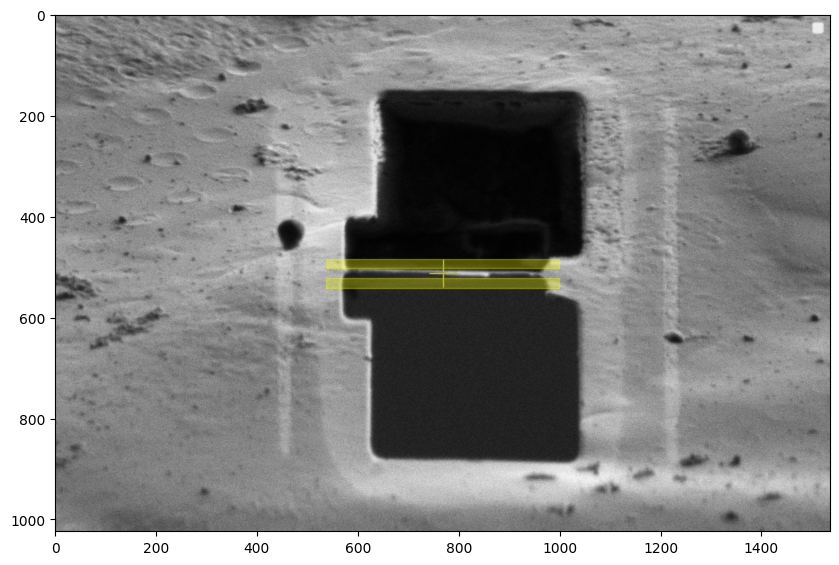

In [6]:
# Place pattern on FIB image from original protocol.yaml file
stages = get_milling_stages("lamella", settings.protocol["milling"])
print(f"Starting with a {stages[0].pattern}")
fig = draw_milling_patterns(ib_image, stages)

In [27]:
def measure_GIS_modified(
    mask_gis_clean: np.array, window_size_m: int, pixel_size_m: float
) -> np.array:
    # Get window size in px
    window_size_px = int(window_size_m / pixel_size_m)
    logging.info(f"window_size_px: {window_size_px}")

    # Calculate average GIS thickness in windows

    # Sum to get thickness along x in pixels
    GIS_pxbypx = np.sum(mask_gis_clean, axis=0).astype(np.float32)

    # Pad with zeros to fulfil window size criteria
    GIS_pxbypx_pad = np.pad(
        GIS_pxbypx,
        (0, window_size_px - len(GIS_pxbypx) % window_size_px),
        constant_values=np.nan,
    )

    # Get left and right limits from where the mean should be calculated from
    GIS_pxbypx_where_above_zero = np.where(GIS_pxbypx_pad > 0)
    xlim_min = GIS_pxbypx_where_above_zero[0][0]  # first occurrence along x
    xlim_max = GIS_pxbypx_where_above_zero[0][-1]  # last occurrence along x

    # make the L and R limits of the lamella x% smaller
    lamella_width_px = xlim_max - xlim_min
    lamella_width_to_cut = int(0.05 * lamella_width_px)  # cut 5% from each end
    xlim_min = lamella_width_to_cut + xlim_min
    xlim_max = xlim_max - lamella_width_to_cut

    GIS_pxbypx_NaNed = np.copy(GIS_pxbypx_pad).astype(np.float32)
    GIS_pxbypx_NaNed[:xlim_min] = np.nan
    GIS_pxbypx_NaNed[xlim_max:] = np.nan

    # This mean will discard nan areas
    # GIS_windowed = np.nanmedian(GIS_pxbypx_NaNed.reshape(-1, window_size_px), axis=1)
    stack = [
        GIS_pxbypx_NaNed[_ : _ + window_size_px]
        for _ in range(GIS_pxbypx_NaNed.size - window_size_px)
    ]
    GIS_windowed = np.nanmedian(
        stack,
        axis=1,
    )
    # Convert to m
    GIS_m = GIS_windowed * pixel_size_m

    # Make any value with 0's, i.e. no GIS measured, NaNs
    GIS_m[np.where(GIS_m == 0)] = np.nan

    return GIS_m, (xlim_min, xlim_max)

2025-01-08 15:32:30,539 — root — INFO — get_prepreds_tfms:59 — imgsize:(1024, 1536), new_size:[512, 768]
2025-01-08 15:32:30,575 — root — INFO — get_prediction:210 — data1.shape:torch.Size([1, 512, 768])
2025-01-08 15:32:30,594 — root — INFO — get_prediction:218 — pred0.shape:torch.Size([1, 4, 512, 768])
2025-01-08 15:32:30,838 — root — INFO — clean_prediction:91 — clean_prediction with prediction.shape:(1024, 1536), pixel_size_m:2.604166666666667e-08
2025-01-08 15:32:30,875 — root — INFO — measure_GIS_modified:6 — window_size_px: 3
2025-01-08 15:32:30,880 — root — INFO — milling_cycle_plot:201 — milling_cycle_plot()
Lamella width is 9.401041666666667e-06 m


C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\gis_measurement.py:80: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  mask_largest_only = skimage.morphology.remove_small_objects(
C:\Users\dmv31621\AppData\Local\Temp\ipykernel_23500\864178448.py:41: RuntimeWarning: All-NaN slice encountered
  GIS_windowed = np.nanmedian(


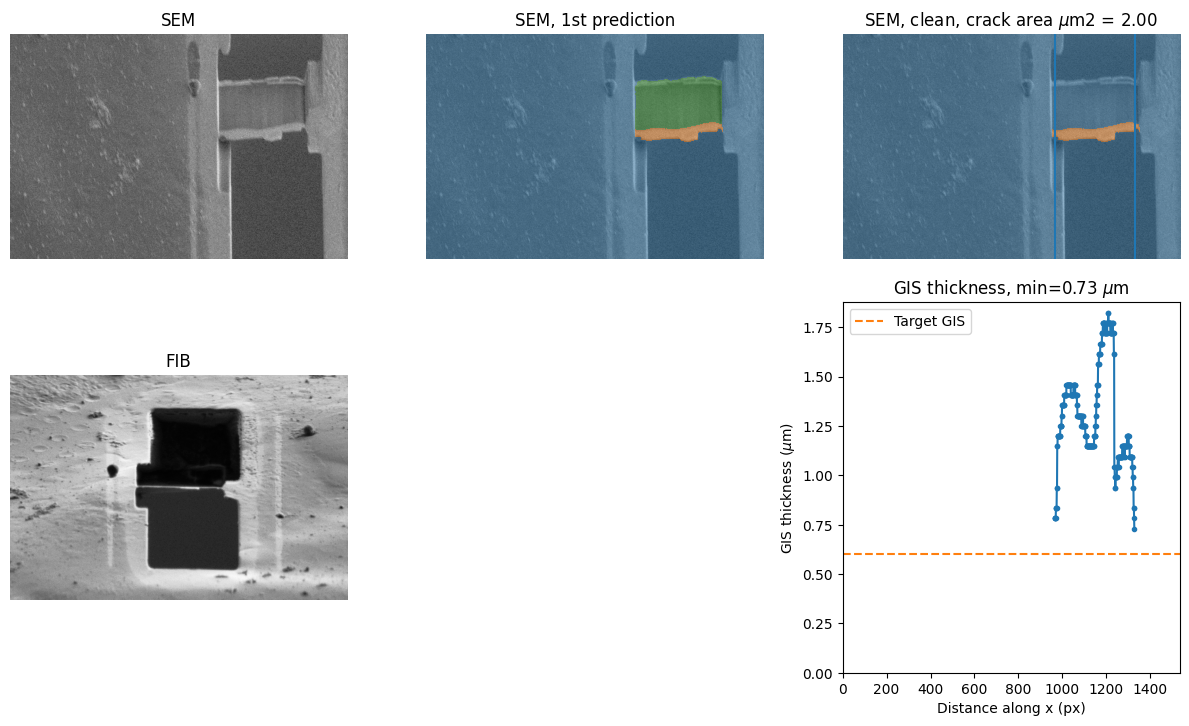

In [30]:
# Find the lamella width based on SEM image segmentation
prediction = gm.segment(eb_image.data)
clean_prediction = gm.clean_prediction(prediction=prediction, pixel_size_m=PIXEL_SIZE_M)
gis_thickness_m, xlims = measure_GIS_modified(mask_gis_clean=clean_prediction, window_size_m=1e-7, pixel_size_m=PIXEL_SIZE_M)
gm.milling_cycle_plot(
    sem_image=eb_image.data,
    first_prediction=prediction,
    clean_prediction=clean_prediction,
    fib_image=ib_image.data,
    gis_thickness_m=gis_thickness_m,
    gis_stop_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]),
    crack_area_m2=float(settings.protocol["adaptive_polish"]["max_crack_area_m2"]),
    xlims=xlims,
    fib_screenshot=None,  # need to figure out how to pass this to plot,
)
lamella_width = (xlims[1] - xlims[0]) * ib_image.metadata.pixel_size.x
print(f"Lamella width is {lamella_width} m")

In [31]:
def create_milling_bitmap_array(
    gis_m: NDArray[np.floating],
    gis_stop_m: float,
    gis_full_power_m: float,
    gis_resolution_m: typing.Union[float, None] = None,
    bitmap_resolution_m: typing.Union[float, None] = None,
    dtype: DTypeLike = np.uint8,
    nan_value: float = 0,
) -> NDArray[typing.Any]:
    """
    Strength multiplier should be between 0 and 1

    If bitmap_resolution_m and gis_resolution_m are None, no pixel interpolation is used.
    """
    dt = np.dtype(dtype)

    assert np.issubdtype(dt, np.integer), "Only integer dtypes accepted"

    n = len(gis_m)
    if gis_resolution_m is None and bitmap_resolution_m is None:
        factor = 1
    elif gis_full_power_m is not None and bitmap_resolution_m is not None:
        factor = bitmap_resolution_m / gis_resolution_m
    else:
        raise TypeError(
            "gis_resolution_m and bitmap_resolution_m must both be None or floats, the types cannot be mixed"
        )

    x = np.linspace(0, n - 1, (n - 1) * factor + 1)
    gis_m = gis_m.copy()
    gis_m[np.isnan(gis_m)] = nan_value
    interpolated = np.interp(x, range(n), gis_m)

    # Rescale to uint8 (clips to 0 at gis_stop_m and 255 at gis_full_power_m)
    rescaled = (
        np.round(
            np.interp(
                interpolated,
                (gis_stop_m, gis_full_power_m),
                (np.iinfo(dt).min, np.iinfo(dt).max),
            )
        )
        .astype(dt)
        .reshape(1, -1)
    )

    return rescaled

2025-01-08 15:24:33,848 — root — INFO — get_prepreds_tfms:59 — imgsize:(1024, 1536), new_size:[512, 768]
2025-01-08 15:24:33,901 — root — INFO — get_prediction:210 — data1.shape:torch.Size([1, 512, 768])
2025-01-08 15:24:34,490 — root — INFO — get_prediction:218 — pred0.shape:torch.Size([1, 4, 512, 768])
2025-01-08 15:24:34,515 — root — INFO — clean_prediction:91 — clean_prediction with prediction.shape:(1024, 1536), pixel_size_m:2.604166666666667e-08
2025-01-08 15:24:34,619 — root — INFO — measure_GIS:118 — window_size_px: 3
2025-01-08 15:24:34,624 — root — INFO — milling_cycle_plot:201 — milling_cycle_plot()
Lamella width is 9.401041666666667e-06 m


C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\gis_measurement.py:80: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  mask_largest_only = skimage.morphology.remove_small_objects(
C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\gis_measurement.py:148: RuntimeWarning: All-NaN slice encountered
  GIS_windowed = np.nanmedian(GIS_pxbypx_NaNed.reshape(-1, window_size_px), axis=1)


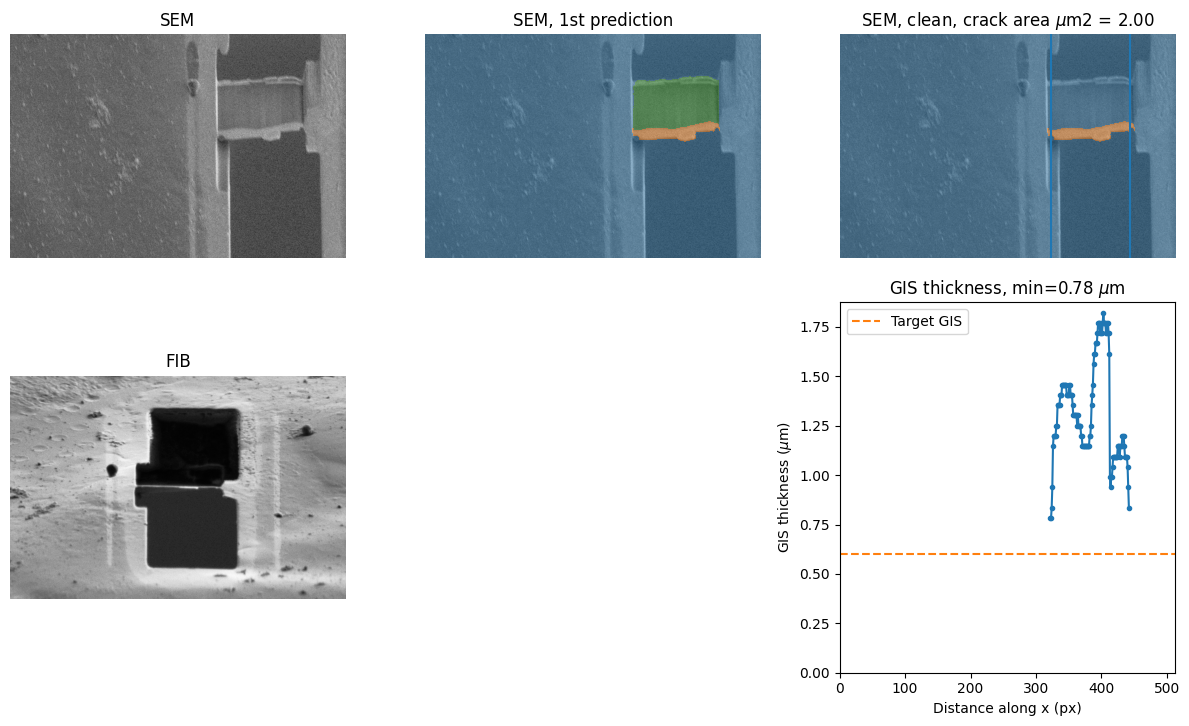

In [9]:
# Find the lamella width based on SEM image segmentation
prediction = gm.segment(eb_image.data)
clean_prediction = gm.clean_prediction(prediction=prediction, pixel_size_m=PIXEL_SIZE_M)
gis_thickness_m, xlims = gm.measure_GIS(mask_gis_clean=clean_prediction, window_size_m=1e-7, pixel_size_m=PIXEL_SIZE_M)
gm.milling_cycle_plot(
    sem_image=eb_image.data,
    first_prediction=prediction,
    clean_prediction=clean_prediction,
    fib_image=ib_image.data,
    gis_thickness_m=gis_thickness_m,
    gis_stop_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]),
    crack_area_m2=float(settings.protocol["adaptive_polish"]["max_crack_area_m2"]),
    xlims=xlims,
    fib_screenshot=None,  # need to figure out how to pass this to plot,
)
lamella_width = (xlims[1] - xlims[0]) * ib_image.metadata.pixel_size.x
print(f"Lamella width is {lamella_width} m")

In [10]:
# bitmap = PIL.Image.fromarray(create_milling_bitmap_array(
#     gis_m=gis_thickness_m,
#     gis_stop_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]),
#     gis_full_power_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]) * 4,
# ))


In [35]:
bitmap_array = create_milling_bitmap_array(
    gis_m=gis_thickness_m[xlims[0]: xlims[1]],
    gis_stop_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]),
    gis_full_power_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]) * 4,
)
# normalise 0-255
# bitmap_array = (bitmap_array / np.max(bitmap_array)) * 255
# bitmap_array.astype(np.uint8)
# Save as .bmp
if bitmaps_path.exists() is False:
    bitmaps_path.mkdir(parents=True)
PIL.Image.fromarray(bitmap_array, mode="L").save(f"{bitmaps_path}/tmp.bmp")

In [36]:
# Change the TrenchPattern from protocol to bitmap with the same dimensions as adaptive polishing
from fibsem.patterning import BitmapPattern

bitmap_config = {
    "width": lamella_width,
    "height": settings.protocol["milling"]["lamella"]["stages"][0]["lamella_height"],
    "depth": settings.protocol["milling"]["lamella"]["stages"][0]["depth"],
    "centre_x":0,
    "centre_y":0,
    "pattern": "BitmapPattern",
    "rotation": 0,
    "cleaning_cross_section": False,
    "scan_direction": "ToptoBottom",
    "path": f"{bitmaps_path}/tmp.bmp",
}
bitmap_pattern_obj = BitmapPattern()
bitmap_pattern_obj.define(protocol=bitmap_config)
stages[0].pattern = bitmap_pattern_obj

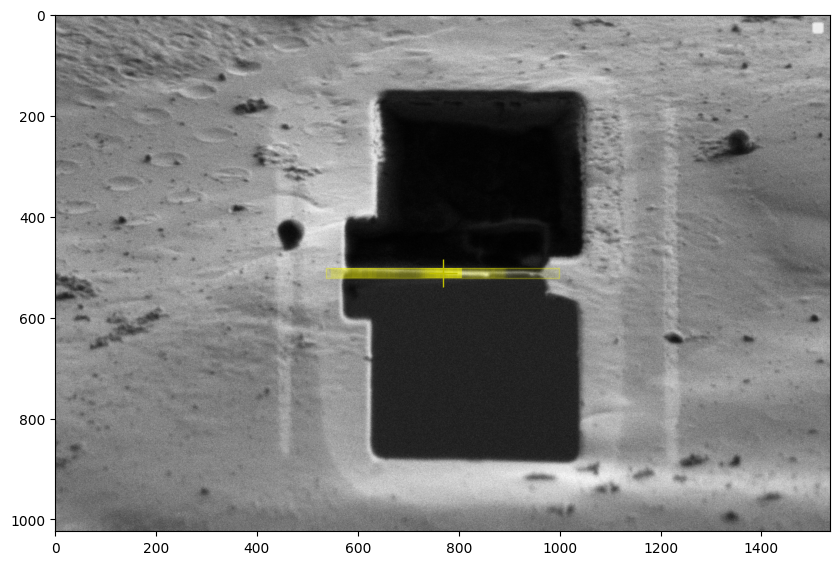

In [37]:
# we should have the bitmap showing up here
fig = draw_milling_patterns(ib_image, stages)

In [15]:
with tempfile.TemporaryFile() as tmp_f:
    bitmap.save(tmp_f, format="BMP")
    # Place pattern on image from edited pattern
    ap_milling_protocol = deepcopy(settings.protocol["milling"]["lamella"]["stages"][-1])
    ap_milling_protocol["lamella_width"] = lamella_width
    ap_milling_protocol["hfw"] = 4e-05
    ap_milling_protocol["trench_height"] = 5e-7
    ap_milling_protocol["name"] = "Adjusted adaptive polishing"
    ap_milling_protocol["type"] = "bitmap"
    ap_milling_protocol["path"] = tmp_f.name
    if settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adaptive polishing":
        settings.protocol["milling"]["lamella"]["stages"].append(ap_milling_protocol)
    elif settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adjusted adaptive polishing":
        settings.protocol["milling"]["lamella"]["stages"][-1] = ap_milling_protocol
    stages = get_milling_stages("lamella", settings.protocol["milling"])
    fig = draw_milling_patterns(ib_image, stages)

NameError: name 'bitmap' is not defined